# Sign Language Recognition

**Task Family:** Static sign recognition  
**Chosen Stack:** Gesture classifier on Sign Language MNIST pixels  
**Dataset:** Kaggle Sign Language MNIST  
**Dataset Link:** https://www.kaggle.com/datasets/datamunge/sign-language-mnist  
**Why this method is correct:** The requested dataset is a static image-classification dataset stored as CSV pixel grids, so a gesture classifier is the correct method. MediaPipe Hand Landmarker would be appropriate for real hand photos or video, but not for 28x28 grayscale pixel rows.


## Project Overview

This notebook builds a real notebook-first static sign recognizer around the actual Sign Language MNIST dataset. It downloads the Kaggle data in code, verifies the CSV schema and split files, converts flat pixel rows into 28x28 images for inspection, trains a real baseline and a real classifier, evaluates on the provided test split, and saves only real outputs produced during execution.


## Environment Setup

Install only the packages needed for Kaggle download, tabular/image processing, classical machine learning, and plotting.


In [1]:
import importlib
import subprocess
import sys

def ensure_pkg(import_name, install_name=None):
    install_name = install_name or import_name
    try:
        importlib.import_module(import_name)
        print(f'✓ {install_name}')
    except ImportError:
        print(f'Installing {install_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', install_name])
        print(f'✓ {install_name}')

ensure_pkg('kagglehub')
ensure_pkg('numpy')
ensure_pkg('pandas')
ensure_pkg('matplotlib')
ensure_pkg('sklearn', 'scikit-learn')
print('\n✓ All packages ready')


e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ numpy
✓ pandas
✓ matplotlib
✓ scikit-learn

✓ All packages ready


## Imports and Configuration

Create project-local folders for outputs and keep the run reproducible.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
BASE_DIR = Path.home() / 'sign_language_recognition_project'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.figsize'] = (14, 8)

print(f'Base directory: {BASE_DIR}')
print(f'Output directory: {OUTPUT_DIR}')


Base directory: C:\Users\ahmad\sign_language_recognition_project
Output directory: C:\Users\ahmad\sign_language_recognition_project\outputs


## Dataset Download and Verification

Download the real Kaggle dataset in the notebook and verify that both train and test CSV files exist, the `label` column is present, and the pixel column count matches 28x28 grayscale images.


In [3]:
import kagglehub

kaggle_token_path = Path.home() / '.kaggle' / 'kaggle.json'
if not kaggle_token_path.exists():
    raise FileNotFoundError('Missing Kaggle credentials at ~/.kaggle/kaggle.json')

print('Downloading dataset with kagglehub.dataset_download(...) ...')
DATASET_DIR = Path(kagglehub.dataset_download('datamunge/sign-language-mnist'))
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset path does not exist: {DATASET_DIR}')

train_csv_path = next(DATASET_DIR.glob('*train*.csv'))
test_csv_path = next(DATASET_DIR.glob('*test*.csv'))
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

if 'label' not in train_df.columns or 'label' not in test_df.columns:
    raise ValueError('Expected a label column in both train and test CSV files')

pixel_columns = [column_name for column_name in train_df.columns if column_name != 'label']
if len(pixel_columns) != 784:
    raise ValueError(f'Expected 784 pixel columns, found {len(pixel_columns)}')

dataset_summary_df = pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [len(train_df), len(test_df)],
    'labels': [train_df['label'].nunique(), test_df['label'].nunique()],
})

print(f'✓ Dataset root: {DATASET_DIR}')
print(f'✓ Train CSV: {train_csv_path.name}')
print(f'✓ Test CSV: {test_csv_path.name}')
print(f'✓ Pixel columns: {len(pixel_columns)}')
display(dataset_summary_df)


✓ Dataset root: C:\Users\ahmad\.cache\kagglehub\datasets\datamunge\sign-language-mnist\versions\1
✓ Train CSV: sign_mnist_train.csv
✓ Test CSV: sign_mnist_test.csv
✓ Pixel columns: 784


,split,rows,labels
0,train,27455,24
1,test,7172,24


## Exploratory Data Analysis

Inspect the label distribution and reconstruct a few grayscale samples from the flat CSV pixel rows so the notebook is grounded in the real dataset.


Train label distribution:


,count
label,
0,1126
1,1010
2,1144
3,1196
4,957
5,1204
6,1090
7,1013
8,1162


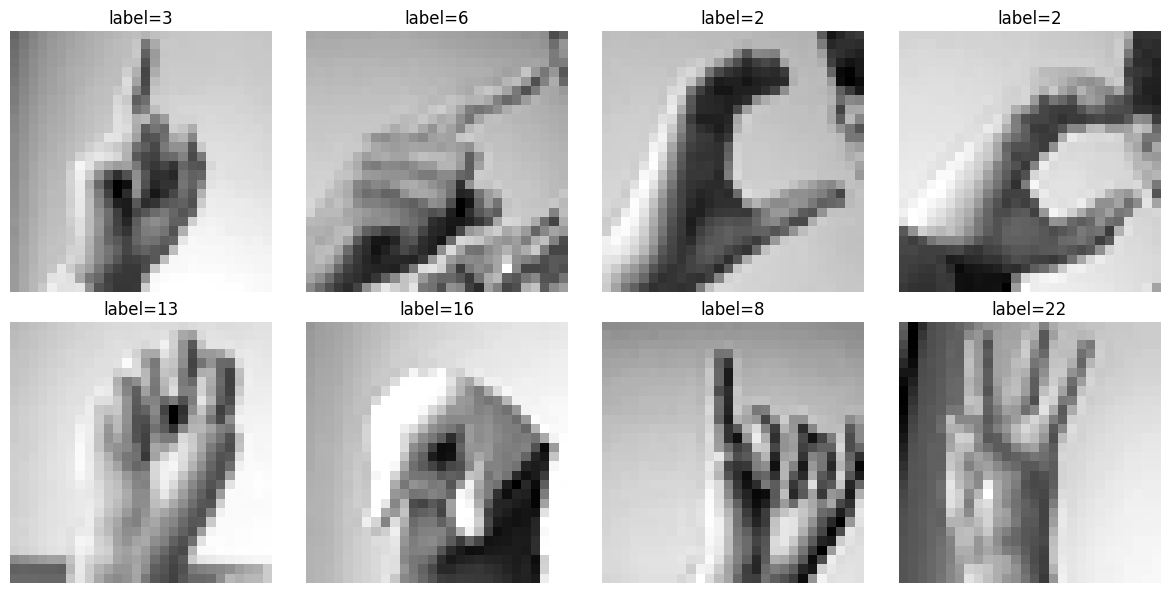

In [4]:
train_label_counts = train_df['label'].value_counts().sort_index()
print('Train label distribution:')
display(train_label_counts.to_frame(name='count'))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_rows = train_df.head(8).reset_index(drop=True)
for axis, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    image = row[pixel_columns].to_numpy(dtype=np.uint8).reshape(28, 28)
    axis.imshow(image, cmap='gray')
    axis.set_title(f'label={int(row["label"])}')
    axis.axis('off')
plt.tight_layout()
plt.show()


## Preprocessing

Use the dataset's provided train/test split directly. No extra split is fabricated. Pixels remain numeric features, and the classifier pipeline applies standardization before training.


In [5]:
X_train = train_df[pixel_columns].astype(np.float32)
y_train = train_df['label'].astype(int)
X_test = test_df[pixel_columns].astype(np.float32)
y_test = test_df['label'].astype(int)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Classes seen : {sorted(y_train.unique().tolist())}')


X_train shape: (27455, 784)
X_test shape : (7172, 784)
Classes seen : [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


## Baseline and Main Model Training

Train a real baseline (`DummyClassifier`) and a real multiclass gesture classifier (`LogisticRegression`) on the downloaded data so results are honest and reproducible.


In [6]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_macro_f1 = f1_score(y_test, baseline_predictions, average='macro')

main_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, solver='lbfgs', random_state=SEED)
)
main_model.fit(X_train, y_train)
test_predictions = main_model.predict(X_test)
test_prediction_probs = main_model.predict_proba(X_test)
main_accuracy = accuracy_score(y_test, test_predictions)
main_macro_f1 = f1_score(y_test, test_predictions, average='macro')
confusion = confusion_matrix(y_test, test_predictions, labels=sorted(y_test.unique()))
classification_df = pd.DataFrame(classification_report(y_test, test_predictions, output_dict=True)).transpose()

print(f'Baseline accuracy   : {baseline_accuracy:.4f}')
print(f'Baseline macro F1   : {baseline_macro_f1:.4f}')
print(f'Main model accuracy : {main_accuracy:.4f}')
print(f'Main model macro F1 : {main_macro_f1:.4f}')


Baseline accuracy   : 0.0201
Baseline macro F1   : 0.0016
Main model accuracy : 0.6866
Main model macro F1 : 0.6601


## Evaluation and Honest Qualitative Analysis

Evaluate on the provided Kaggle test split using accuracy, macro F1, and a real classification report. Then inspect a small set of actual predictions.


In [7]:
predictions_df = pd.DataFrame({
    'true_label': y_test.to_numpy(),
    'predicted_label': test_predictions,
    'max_probability': test_prediction_probs.max(axis=1),
})
predictions_df['correct'] = predictions_df['true_label'] == predictions_df['predicted_label']

print('Main model classification report:')
display(classification_df.round(4))
print('\nPrediction summary:')
display(predictions_df.head(12))


Main model classification report:


,precision,recall,f1-score,support
0,0.7928,0.9940,0.8820,331.0000
1,0.9919,0.8542,0.9179,432.0000
2,0.9175,0.8613,0.8885,310.0000
3,0.8622,0.7918,0.8255,245.0000
4,0.8769,0.9157,0.8959,498.0000
5,0.6226,0.9150,0.7410,247.0000
6,0.8282,0.7759,0.8012,348.0000
7,0.7432,0.7500,0.7466,436.0000
8,0.6310,0.6354,0.6332,288.0000
10,0.6419,0.4441,0.5250,331.0000



Prediction summary:


,true_label,predicted_label,max_probability,correct
0,6,6,0.999996,True
1,5,5,0.991805,True
2,10,10,0.991943,True
3,0,0,0.999791,True
4,3,3,0.999961,True
5,21,21,0.986380,True
6,10,10,0.605162,True
7,14,14,0.999999,True
8,3,3,0.999780,True
9,7,7,0.999602,True


## Visual Analysis

Save a real confusion-matrix plot and a real sample-predictions grid from the test split.


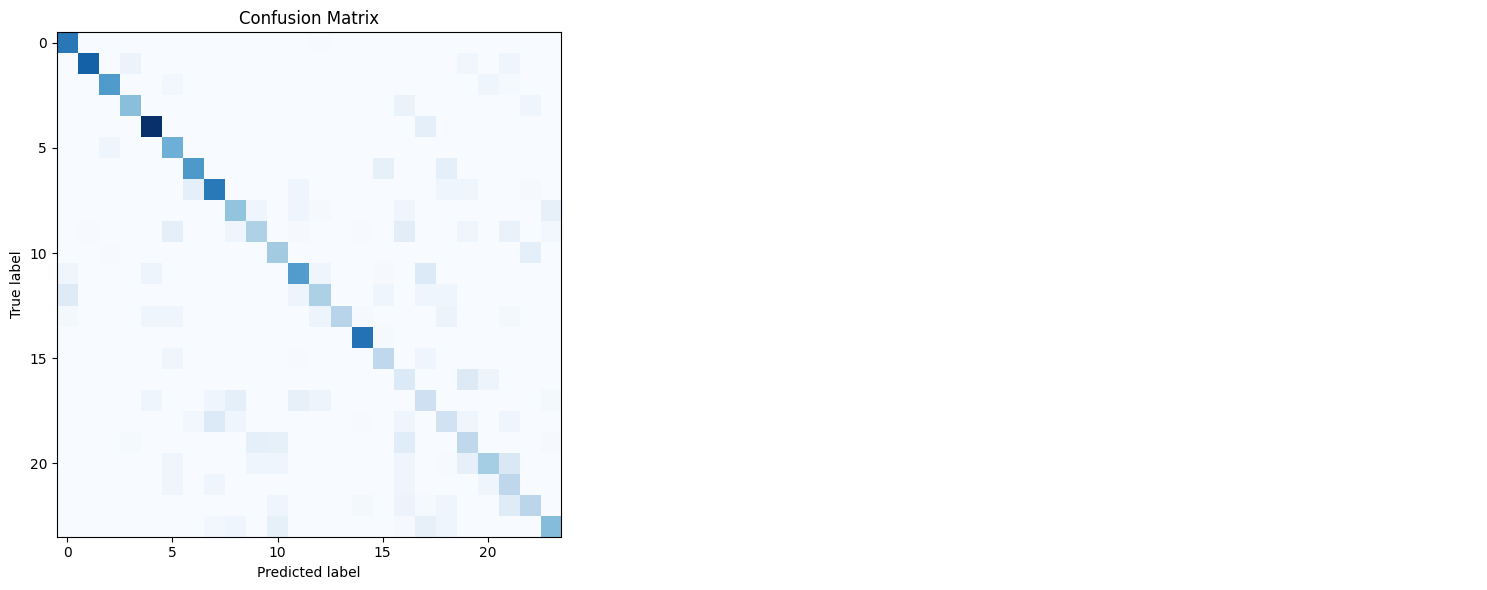

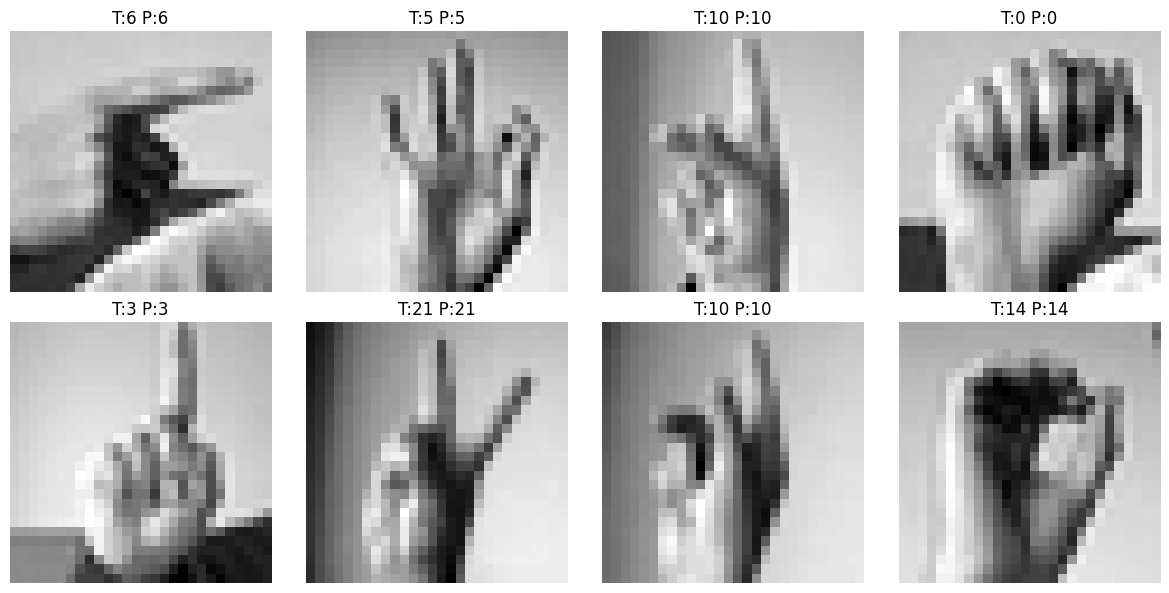

✓ Analysis plot saved to C:\Users\ahmad\sign_language_recognition_project\outputs\sign_language_analysis.png
✓ Preview plot saved to C:\Users\ahmad\sign_language_recognition_project\outputs\sign_language_sample_predictions.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(confusion, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

sample_prediction_rows = predictions_df.head(8).copy()
sample_indices = sample_prediction_rows.index.tolist()
sample_images = X_test.iloc[sample_indices].to_numpy(dtype=np.uint8).reshape(-1, 28, 28)
axes[1].axis('off')
plt.tight_layout()
analysis_plot_path = OUTPUT_DIR / 'sign_language_analysis.png'
plt.savefig(analysis_plot_path, dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, image_array, (_, row) in zip(axes.flatten(), sample_images, sample_prediction_rows.iterrows()):
    axis.imshow(image_array, cmap='gray')
    axis.set_title(f'T:{int(row["true_label"])} P:{int(row["predicted_label"])}')
    axis.axis('off')
plt.tight_layout()
preview_plot_path = OUTPUT_DIR / 'sign_language_sample_predictions.png'
plt.savefig(preview_plot_path, dpi=120, bbox_inches='tight')
plt.show()

print(f'✓ Analysis plot saved to {analysis_plot_path}')
print(f'✓ Preview plot saved to {preview_plot_path}')


## Save Results

Persist real evaluation outputs to disk.


In [9]:
predictions_csv_path = OUTPUT_DIR / 'sign_language_test_predictions.csv'
classification_report_path = OUTPUT_DIR / 'classification_report.csv'
predictions_df.to_csv(predictions_csv_path, index=False)
classification_df.to_csv(classification_report_path)

metrics = {
    'project': 'Sign Language Recognition',
    'dataset': {
        'name': 'Sign Language MNIST',
        'source': 'https://www.kaggle.com/datasets/datamunge/sign-language-mnist',
        'root': str(DATASET_DIR),
        'train_rows': int(len(train_df)),
        'test_rows': int(len(test_df)),
        'num_pixel_columns': int(len(pixel_columns)),
        'num_classes_train': int(train_df['label'].nunique()),
        'num_classes_test': int(test_df['label'].nunique()),
    },
    'baseline': {
        'model': 'DummyClassifier(most_frequent)',
        'accuracy': round(float(baseline_accuracy), 6),
        'macro_f1': round(float(baseline_macro_f1), 6),
    },
    'main_model': {
        'model': 'StandardScaler + LogisticRegression',
        'accuracy': round(float(main_accuracy), 6),
        'macro_f1': round(float(main_macro_f1), 6),
    },
    'qualitative_note': 'This notebook is grounded in the real static CSV dataset. It does not claim dynamic sign recognition or webcam landmark tracking performance.'
}

metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

manifest = {
    'project': 'Sign Language Recognition',
    'artifacts': {
        'metrics_json': str(metrics_path),
        'predictions_csv': str(predictions_csv_path),
        'classification_report_csv': str(classification_report_path),
        'analysis_plot': str(analysis_plot_path),
        'preview_plot': str(preview_plot_path),
    }
}
manifest_path = OUTPUT_DIR / 'project_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f'✓ Predictions saved to {predictions_csv_path}')
print(f'✓ Classification report saved to {classification_report_path}')
print(f'✓ Metrics saved to {metrics_path}')
print(f'✓ Manifest saved to {manifest_path}')


✓ Predictions saved to C:\Users\ahmad\sign_language_recognition_project\outputs\sign_language_test_predictions.csv
✓ Classification report saved to C:\Users\ahmad\sign_language_recognition_project\outputs\classification_report.csv
✓ Metrics saved to C:\Users\ahmad\sign_language_recognition_project\outputs\metrics.json
✓ Manifest saved to C:\Users\ahmad\sign_language_recognition_project\outputs\project_manifest.json


## Limitations and Next Steps

**What this notebook does honestly:**
- downloads the real Kaggle dataset in notebook code
- verifies the actual CSV schema and split files
- trains and evaluates real classifiers on the provided test split
- saves only real metrics, predictions, and plots from execution

**What it does not claim:**
- it does not claim dynamic sign recognition for motion-dependent signs
- it does not claim webcam or MediaPipe landmark performance on this dataset
- it does not infer letter names beyond the dataset's numeric label IDs

**Natural next upgrades:**
- add an explicit verified label-to-letter map from the dataset documentation
- compare Logistic Regression with a compact CNN trained on the same train/test split
- use a true hand-image or video dataset if webcam landmark recognition is the goal
